# Notebook to run transfer learning on IRD patients using pretrained model

## Library Imports

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from retinal_seg.config import BATCH_SIZE, EPOCHS, IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES
from retinal_seg.data.loader import datasets_from_maps, train_val_test_split
from retinal_seg.model.losses import dice_coef, weighted_ce_dice
from retinal_seg.model.unet import build_unet

In [3]:
FIG_DIR = Path(os.getcwd()).parent / "figures" / "ird_domain_adaption"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = (
    Path(os.getcwd()).parent / "trained_models_checkpoint" / "ird_domain_adaption"
)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## Get paths for train/ valid and test set

In [4]:
# Files are stored within this directory
directory = (
    Path(os.getcwd()).parent.parent / "diseased_1509/Segmentierung_Dicom_14.9_IRD"
)
x_path = []
y_path = []

x_y_map = {}

for file in sorted(os.listdir(directory)):
    filename = os.fsdecode(file)
    if filename.endswith(".npy") and "Final" not in filename:
        idx_x = filename.split(".npy")[0].split("_")[-1]
        x_y_map[str(directory) + "/" + filename] = (
            str(directory)
            + "/"
            + filename.split(".")[0]
            + f"_Surfaces_Retina-JEI-Final_{idx_x}.npy"
        )

In [5]:
len(x_y_map)

1225

## Get class distribution

In [6]:
# class_0, class_1, class_2, class_3 = get_class_distribution(x_y_map)
# print(class_0, class_1, class_2, class_3)

## Split training set by patient names 
#### Patient name defined as first two words seperated by "_" within file name

In [ ]:
train_x_y_map, val_x_y_map, test_x_y_map = train_val_test_split(x_y_map, val_ratio=0.1, test_ratio=0.1)

## Define dataloader


In [ ]:
train_dataset, val_dataset, test_dataset = datasets_from_maps(train_x_y_map, val_x_y_map, test_x_y_map, batch_size=BATCH_SIZE)

In [ ]:
SHUFFLE_BUFFER_SIZE = 1

## Define model and freeze all layers apart of BN layers

In [ ]:
model_new = build_unet(
    pretrained_weights="../../retina-segmentation/trained_models_checkpoint/ird_domain_adaption",
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    img_channels=IMG_CHANNELS,
    n_classes=NUM_CLASSES,
    last_activation="softmax",
    compile_model=True,
    bn_list=[True] * 14,
    drop_rate=0.0,
    non_local_attention=False,
    momentum=0.9,
    loss=weighted_ce_dice,
)

In [13]:
for layer in model_new.layers:
    if "batch_normalization" not in layer.name:
        layer.trainable = False
    else:
        print("Trainable lay: ", layer.name)

Trainable lay:  batch_normalization
Trainable lay:  batch_normalization_1
Trainable lay:  batch_normalization_2
Trainable lay:  batch_normalization_3
Trainable lay:  batch_normalization_4
Trainable lay:  batch_normalization_5
Trainable lay:  batch_normalization_6
Trainable lay:  batch_normalization_7
Trainable lay:  batch_normalization_8
Trainable lay:  batch_normalization_9
Trainable lay:  batch_normalization_10
Trainable lay:  batch_normalization_11
Trainable lay:  batch_normalization_12
Trainable lay:  batch_normalization_13


## Train model

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model_new.fit(
    train_dataset, validation_data=val_dataset, epochs=30, callbacks=[early_stopping]
)

Epoch 1/30
tf.Tensor([[1.  1.  3.5 1. ]], shape=(1, 4), dtype=float32)
tf.Tensor([[1.  1.  3.5 1. ]], shape=(1, 4), dtype=float32)
117/117 [==============================] - 61s 521ms/step - loss: 0.0988 - dice_coef: 0.9727 - val_loss: 0.0787 - val_dice_coef: 0.9829
Epoch 2/30
117/117 [==============================] - 59s 503ms/step - loss: 0.0656 - dice_coef: 0.9820 - val_loss: 0.0681 - val_dice_coef: 0.9854
Epoch 3/30
117/117 [==============================] - 59s 506ms/step - loss: 0.0554 - dice_coef: 0.9847 - val_loss: 0.0614 - val_dice_coef: 0.9867
Epoch 4/30
117/117 [==============================] - 59s 507ms/step - loss: 0.0498 - dice_coef: 0.9863 - val_loss: 0.0622 - val_dice_coef: 0.9869
Epoch 5/30
117/117 [==============================] - 60s 509ms/step - loss: 0.0465 - dice_coef: 0.9872 - val_loss: 0.0640 - val_dice_coef: 0.9872
Epoch 6/30
117/117 [==============================] - 60s 510ms/step - loss: 0.0436 - dice_coef: 0.9880 - val_loss: 0.0634 - val_dice_coef: 0.987

In [15]:
model_new.save_weights(MODEL_DIR)

## Get overall test dice and ONL Dice

In [25]:
test_dataset_batch = test_dataset.batch(BATCH_SIZE)
dice_coefs_test = []
dice_coefs_test_onl = []
for test in test_dataset_batch:
    pred = model_new.predict(test[0])
    dice_coef_ = dice_coef(test[1], pred)
    dice_coefs_test.append(dice_coef_)

    dice_coef_onl = dice_coef(test[1][:, :, :, 2], pred[:, :, :, 2])
    dice_coefs_test_onl.append(dice_coef_onl)


print(np.mean(dice_coefs_test))

print(np.mean(dice_coefs_test_onl))

0.98819983
0.70230055


## Validation dice

In [26]:
dice_coefs_test = []
dice_coefs_test_onl = []
for test in val_dataset:
    pred = model_new.predict(test[0])
    dice_coef_ = dice_coef(test[1], pred)
    dice_coefs_test.append(dice_coef_)

    dice_coef_onl = dice_coef(test[1][:, :, :, 2], pred[:, :, :, 2])
    dice_coefs_test_onl.append(dice_coef_onl)


print(np.mean(dice_coefs_test))

print(np.mean(dice_coefs_test_onl))

0.9866867
0.5750778


## Plot results of test set

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/ipykernel/__main__.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


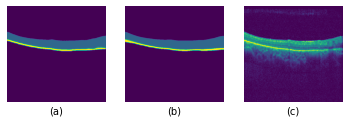

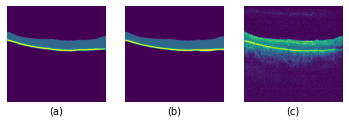

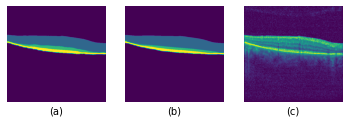

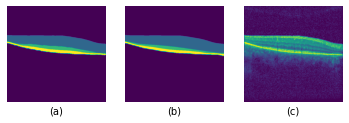

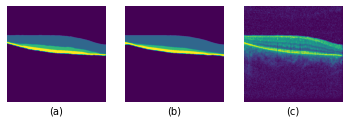

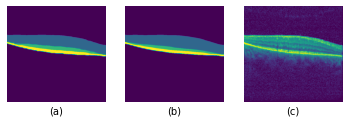

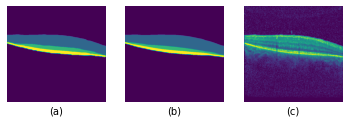

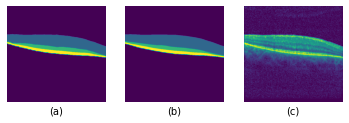

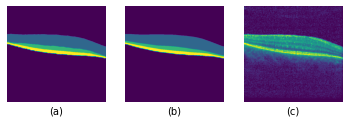

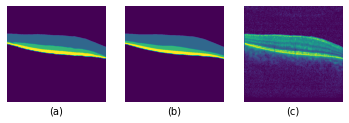

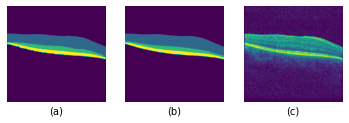

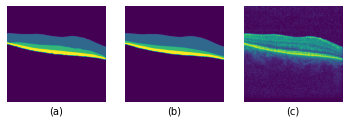

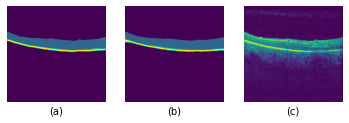

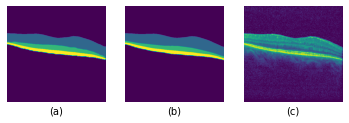

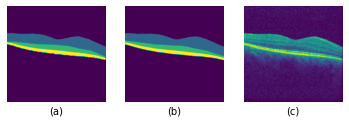

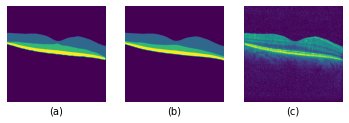

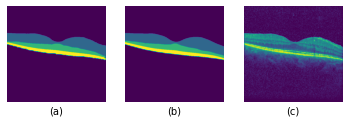

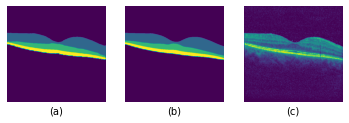

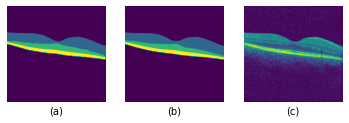

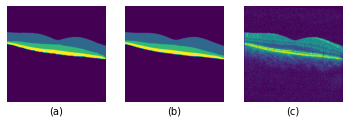

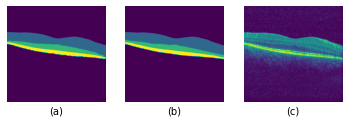

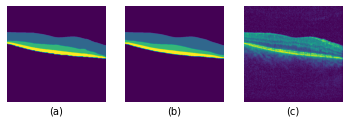

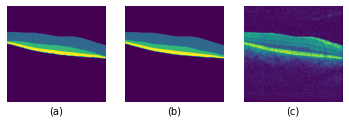

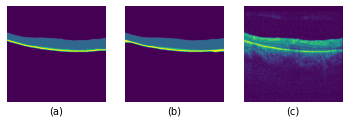

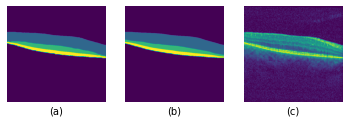

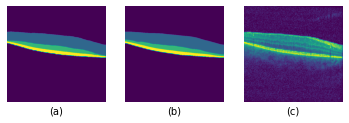

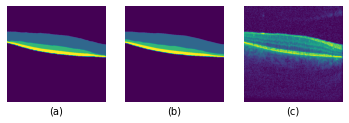

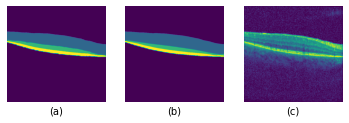

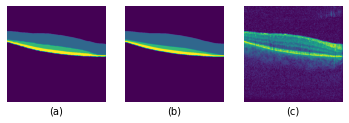

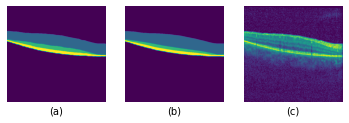

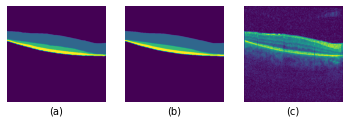

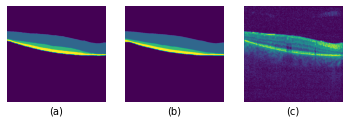

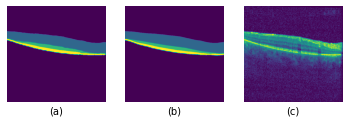

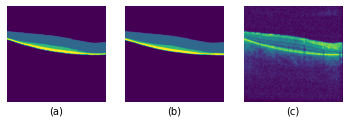

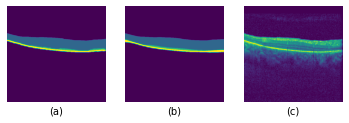

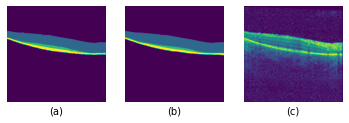

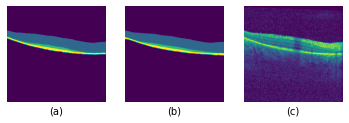

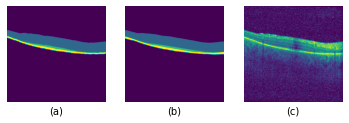

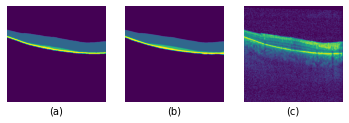

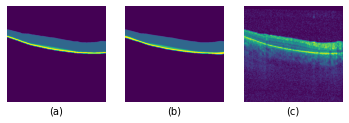

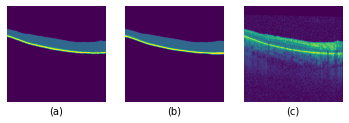

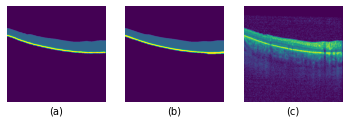

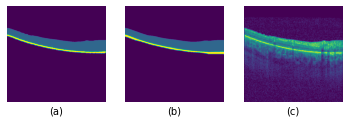

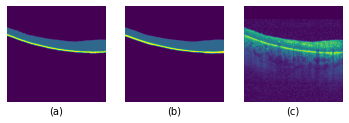

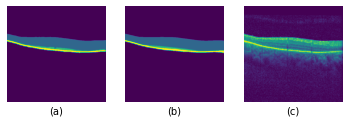

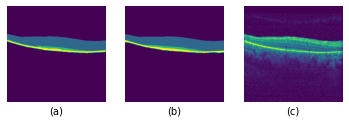

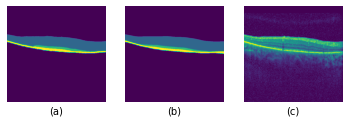

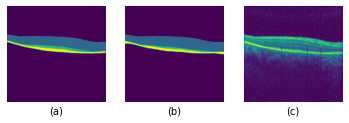

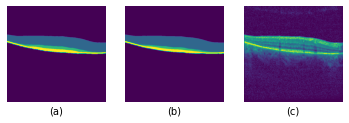

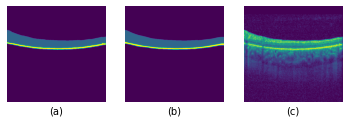

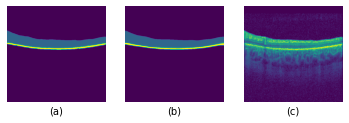

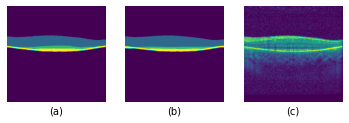

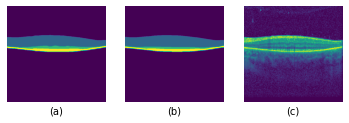

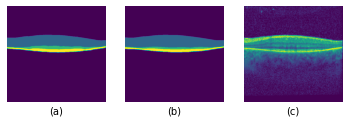

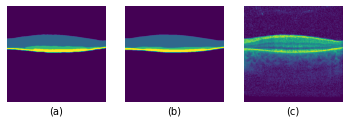

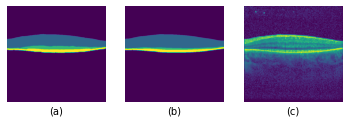

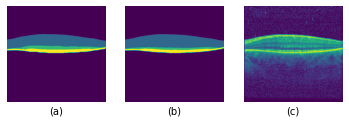

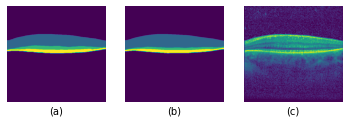

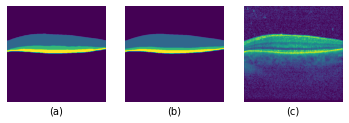

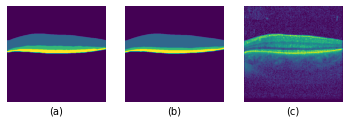

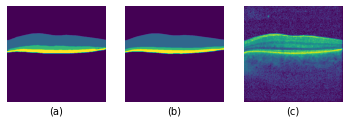

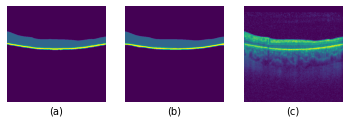

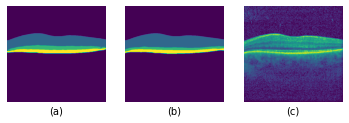

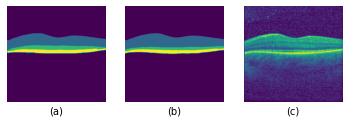

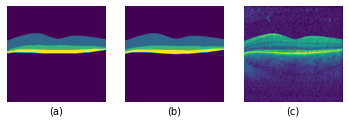

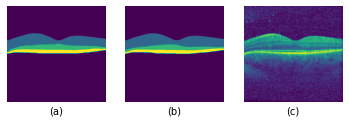

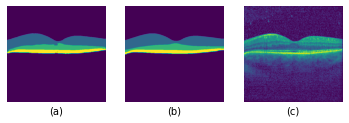

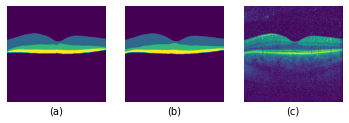

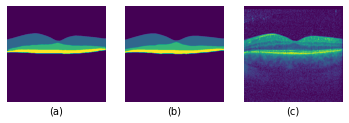

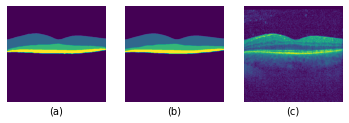

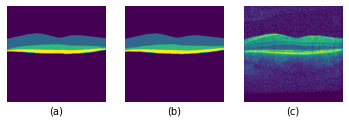

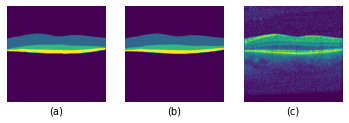

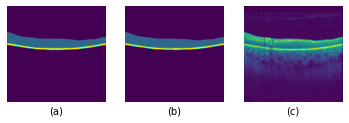

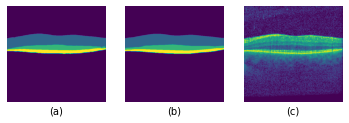

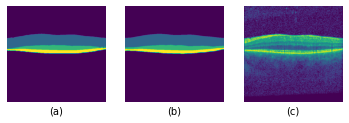

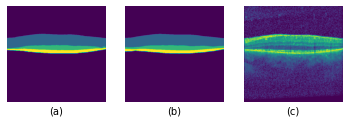

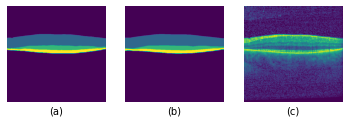

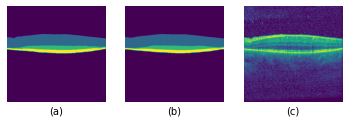

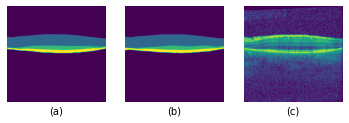

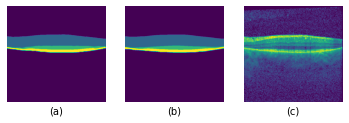

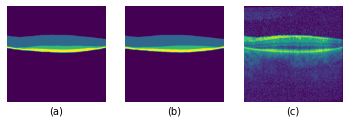

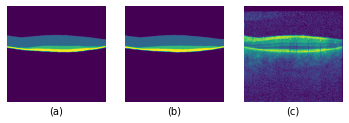

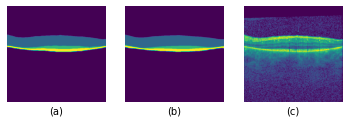

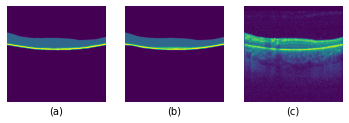

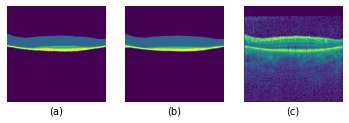

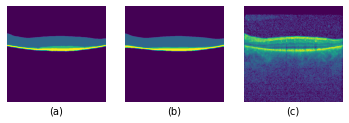

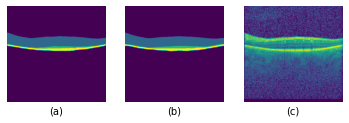

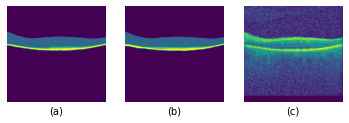

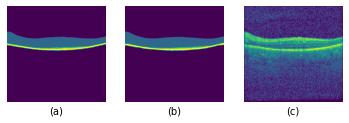

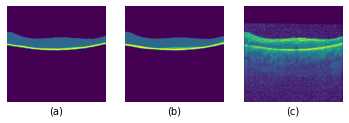

In [14]:
test = test_dataset.shuffle(SHUFFLE_BUFFER_SIZE)
test = test.take(90)

for idx, i in enumerate(test):
    pred = model_new.predict(np.expand_dims(i[0], axis=0))
    pred = np.argmax(pred, axis=-1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax1.imshow(pred[0])
    ax2.imshow(np.argmax(i[1], axis=-1))
    ax3.imshow(i[0])
    ax1.set_xlabel("(a)")
    ax2.set_xlabel("(b)")
    ax3.set_xlabel("(c)")
    ax1.set_frame_on(False)
    ax2.set_frame_on(False)
    ax3.set_frame_on(False)
    plt.savefig(FIG_DIR / f"test_set_{idx}.png", dpi=500)

## Plot results of valid set

In [ ]:
_, val_dataset_viz, _ = datasets_from_maps(train_x_y_map, val_x_y_map, test_x_y_map, batch_size=BATCH_SIZE)
test = val_dataset_viz.unbatch().shuffle(SHUFFLE_BUFFER_SIZE).take(100)

for idx, i in enumerate(test):
    pred = model_new.predict(np.expand_dims(i[0], axis=0))
    pred = np.argmax(pred, axis=-1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ax1.imshow(pred[0])
    ax2.imshow(np.argmax(i[1], axis=-1))
    ax3.imshow(i[0])
    ax1.set_xlabel("(a)")
    ax2.set_xlabel("(b)")
    ax3.set_xlabel("(c)")
    ax1.set_frame_on(False)
    ax2.set_frame_on(False)
    ax3.set_frame_on(False)
    plt.savefig(FIG_DIR / f"valid_set_{idx}.png", dpi=500)